# 02 Deblurring Diffusion (Gaussian Blur)

This notebook demonstrates the Cold Diffusion process using deterministic Gaussian Blur as the degradation, diverging from the traditional Gaussian Noise used in standard diffusion models.

## Table of Contents
1. [Environment Setup & Imports](#1.-Environment-Setup-&-Imports)
2. [Dataset Preparation](#2.-Dataset-Preparation)
3. [Model & Diffusion Initialization](#3.-Model-&-Diffusion-Initialization)
4. [Trainer Configuration](#4.-Trainer-Configuration)
5. [Forward Degradation Visualization](#5.-Forward-Degradation-Visualization)
6. [Training Process](#6.-Training-Process)
7. [Backward Process (Sampling)](#7.-Backward-Process-(Sampling))

## 1. Environment Setup & Imports
In this section, we import the standard libraries and PyTorch components. We also modify the system path so that the notebook can successfully import modules from the project's root repository (`deblurring-diffusion-pytorch`), avoiding hardcoded paths. Lastly, we set our execution device (CUDA or CPU).

In [1]:
import sys
import os
from pathlib import Path
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Add paths dynamically
REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'deblurring-diffusion-pytorch'))

from deblurring_diffusion_pytorch import GaussianDiffusion, Trainer, Model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset Preparation
We establish the root directory for the CIFAR-10 dataset. This dataset was globally prepared and formatted by `00_setup_and_data_preparation.ipynb`. By referencing this pre-built directory, we avoid duplicating extraction and downloading tasks.

In [2]:
# The dataset is already prepared by notebook 00.
dataset_root = REPO_ROOT / 'data' / 'root_cifar10'
root = str(dataset_root)
print(f"Using pre-prepared dataset located at: {root}")

Using pre-prepared dataset located at: /workspace/data/root_cifar10


## 3. Model & Diffusion Initialization
Here we define the core architecture. We instantiate the neural network `Model` tailored for CIFAR-10, characterized by 3-channel input/output and multiple residual blocks. We then encapsulate this model inside the `GaussianDiffusion` framework. Crucially for deblurring, we apply the `Incremental` blur routine, the `Final` training objective, and the `x0_step_down` sampling method.

In [3]:
# Initialize the model and diffusion modules
model = Model(resolution=32,
              in_channels=3,
              out_ch=3,
              ch=128,
              ch_mult=(1,2,2,2),
              num_res_blocks=2,
              attn_resolutions=(16,),
              dropout=0.1).to(DEVICE)

diffusion = GaussianDiffusion(
    model,
    image_size = 32,
    device_of_kernel = DEVICE,
    channels = 3,
    timesteps = 50,
    loss_type = 'l1',
    kernel_std=0.1,
    kernel_size=3,
    blur_routine='Incremental',
    train_routine='Final',
    sampling_routine='x0_step_down',
    discrete=False
).to(DEVICE)

print("Model and GaussianDiffusion initialized successfully.")

Model and GaussianDiffusion initialized successfully.


## 4. Trainer Configuration
The `Trainer` handles dataset loading via PyTorch DataLoaders, optimizer scheduling, EMA updates, and checkpointing. We initialize it to run training iterations in small batches.

In [4]:
# Set up Trainer
save_folder = str(REPO_ROOT / 'results_deblurring-diffusion-pytorch')
os.makedirs(save_folder, exist_ok=True)

trainer = Trainer(
    diffusion,
    root,
    image_size = 32,
    train_batch_size = 32,
    train_lr = 2e-5,
    train_num_steps = 700000, # Official paper hyperparameter
    gradient_accumulate_every = 2,
    ema_decay = 0.995,
    fp16 = False,
    results_folder = save_folder,
    dataset = 'cifar10'
)
print("Trainer initialized.")

cifar10 DA used
Trainer initialized.


## 5. Forward Degradation Visualization
To understand how Cold Diffusion differs from traditional diffusion, we extract a single image batch (`x0`) and simulate the forward pass (`q_sample`). By charting multiple timesteps side-by-side, we can observe the image progressively losing detail and becoming deterministically blurred without injecting random noise.

Loaded batch of shape torch.Size([32, 3, 32, 32])


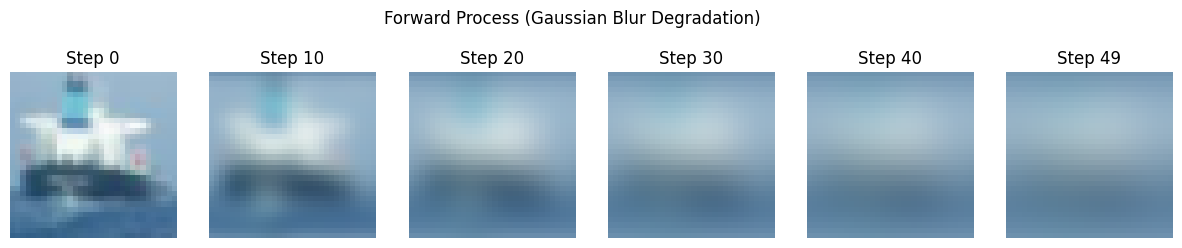

In [5]:
# Visualize Forward Process
# Get a batch of images to act as x0
batch = next(trainer.dl)
# Unpack if the dataloader yields (img, label) tuple
if isinstance(batch, (tuple, list)):
    x0 = batch[0]
else:
    x0 = batch

x0 = x0.to(DEVICE)
print(f"Loaded batch of shape {x0.shape}")

# Take the first image in the batch
x0_single = x0[0:1]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
timesteps_to_plot = [0, 10, 20, 30, 40, 49]

def unnormalize_to_numpy(tensor):
    img = tensor.cpu().detach().numpy()
    # Handle normalizations gracefully
    if img.min() < -0.1:
        img = (img + 1) * 0.5 
    img = np.clip(img, 0, 1)
    if img.shape[0] == 3: # CxHxW to HxWxC
        img = np.transpose(img, (1, 2, 0))
    elif img.shape[0] == 1:
        img = img[0]
    return img

for i, t_val in enumerate(timesteps_to_plot):
    t_tensor = torch.full((1,), t_val, device=DEVICE, dtype=torch.long)
    x_t = diffusion.q_sample(x_start=x0_single, t=t_tensor)
    
    img_np = unnormalize_to_numpy(x_t[0])
    axes[i].imshow(img_np, cmap='gray' if len(img_np.shape) == 2 else None)
    axes[i].set_title(f"Step {t_val}")
    axes[i].axis("off")

plt.suptitle("Forward Process (Gaussian Blur Degradation)")
plt.show()

## 6. Training Process
We execute a short training loop. During each iteration, the model observes heavily blurred states and is penalized (via L1 loss) on how accurately it can predict the completely clean `x0` image directly from that blurred state.

In [ ]:
print("Running training iterations...")
trainer.train()
print("Training iterations completed.")

Running training iterations...
0: 0.43711158633232117
0: 0.45388662815093994
100: 0.1700928509235382
100: 0.17151308059692383


## 7. Backward Process (Sampling)
Finally, we run the inverse process. Using Algorithm 2 (`x0_step_down`), the model generates a clean prediction from complete blur, steps backwards slightly, and refines the prediction over multiple iterations until a fully restored and sharp sample is generated.

In [ ]:
# Full Qualitative Results: Forward and Backward Process
print('Visualizing the full degradation and restoration cycle...')

# We use a single batch of images for the full cycle
batch = next(trainer.dl)
if isinstance(batch, (tuple, list)):
    x0 = batch[0]
else:
    x0 = batch
x0 = x0.to(DEVICE)

# Select 4 images to showcase
x0_showcase = x0[:4]

# Forward process: generating maximum degradation (t=50)
t_max = torch.full((4,), 49, device=DEVICE, dtype=torch.long)
x_t = diffusion.q_sample(x_start=x0_showcase, t=t_max)

# Backward process: reversing the degradation
print('Sampling images using x0_step_down routine...')
# The sample method requires the original images to correctly compute absolute degradation steps
sampled_images = diffusion.sample(batch_size=4, img=x0_showcase)

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
axes[0, 0].set_title('Original (x0)')
axes[0, 1].set_title('Degraded (x_T)')
axes[0, 2].set_title('Restored (x0_hat)')

for i in range(4):
    # Original
    img_orig = unnormalize_to_numpy(x0_showcase[i])
    axes[i, 0].imshow(img_orig, cmap='gray' if len(img_orig.shape) == 2 else None)
    axes[i, 0].axis('off')
    
    # Degraded
    img_deg = unnormalize_to_numpy(x_t[i])
    axes[i, 1].imshow(img_deg, cmap='gray' if len(img_deg.shape) == 2 else None)
    axes[i, 1].axis('off')
    
    # Restored
    img_restored = unnormalize_to_numpy(sampled_images[i])
    axes[i, 2].imshow(img_restored, cmap='gray' if len(img_restored.shape) == 2 else None)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
